6. In this exercise, you will further analyze the Wage data set considered
throughout this chapter.

(a) Perform polynomial regression to predict wage using age. Use</br>
cross-validation to select the optimal degree d for the polyno-</br>
mial. What degree was chosen, and how does this compare to</br>
the results of hypothesis testing using ANOVA? Make a plot of</br>
the resulting polynomial fit to the data.</br>

最佳 degree = 6


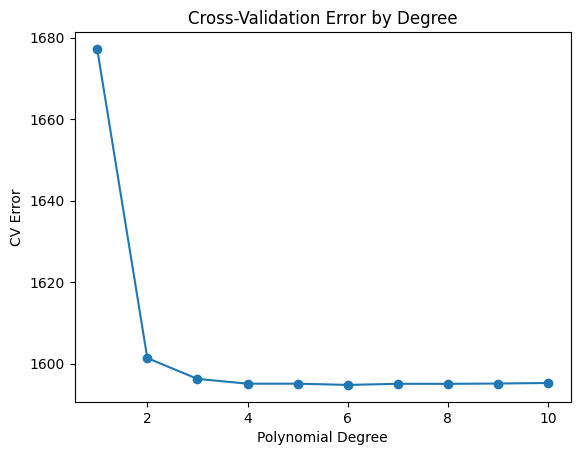

/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  "X does not have valid feature names, but"


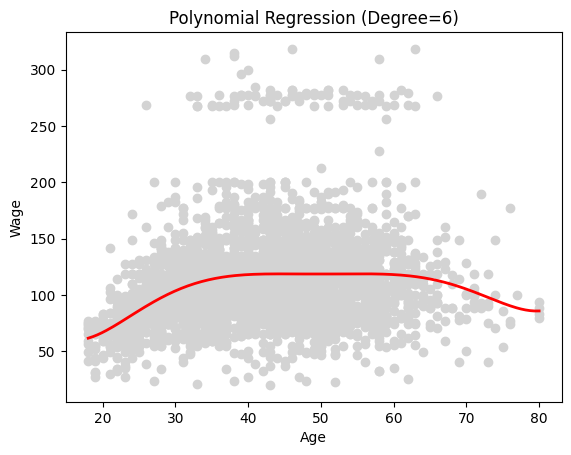

In [ ]:
from ISLP import load_data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

wage = load_data('Wage')

X = wage[['age']]
y = wage['wage']

degrees = range(1, 11)
cv_errors = []

kf = KFold(n_splits=10, shuffle=True, random_state=1)

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    mse = -cross_val_score(model, X_poly, y, cv=kf,
                           scoring='neg_mean_squared_error').mean()
    cv_errors.append(mse)

best_d = degrees[np.argmin(cv_errors)]
print("最佳 degree =", best_d)

# 畫出 CV error vs degree
plt.plot(degrees, cv_errors, marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("CV Error")
plt.title("Cross-Validation Error by Degree")
plt.show()

# 最佳多項式回歸曲線
# 使用最佳 degree 建模
poly = PolynomialFeatures(degree=best_d, include_bias=False)
X_poly = poly.fit_transform(X)

model = LinearRegression().fit(X_poly, y)

age_grid = np.linspace(X.age.min(), X.age.max(), 200).reshape(-1, 1)
age_poly = poly.transform(age_grid)
pred = model.predict(age_poly)
plt.scatter(X.age, y, color="lightgray")
plt.plot(age_grid, pred, color="red", linewidth=2)
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title(f"Polynomial Regression (Degree={best_d})")
plt.show()



(b) Fit a step function to predict wage using age, and perform cross-</br>
validation to choose the optimal number of cuts. Make a plot of</br>
the fit obtained.</br>

最佳切割數 = 8


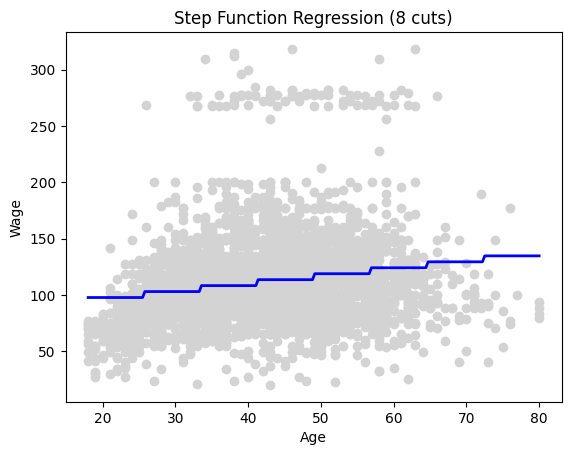

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import KBinsDiscretizer

X = wage[['age']]
y = wage['wage']

cuts_list = range(2, 11)
cv_errors = []

kf = KFold(n_splits=10, shuffle=True, random_state=1)

for cuts in cuts_list:
    kb = KBinsDiscretizer(n_bins=cuts, encode='onehot-dense', strategy='uniform')
    X_cut = kb.fit_transform(X)

    model = LinearRegression()
    mse = -cross_val_score(model, X_cut, y, cv=kf,
                           scoring='neg_mean_squared_error').mean()
    cv_errors.append(mse)

best_cut = cuts_list[np.argmin(cv_errors)]
print("最佳切割數 =", best_cut)

kb = KBinsDiscretizer(n_bins=best_cut, encode="ordinal", strategy="uniform")
age_cut = kb.fit_transform(age_grid)

pred = []
model = LinearRegression().fit(kb.fit_transform(X), y)
pred = model.predict(age_cut)

plt.scatter(X.age, y, color="lightgray")
plt.plot(age_grid, pred, color="blue", linewidth=2)
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title(f"Step Function Regression ({best_cut} cuts)")
plt.show()
